# Lecture 1 — Why Deep Learning Systems

**CMU 10-414/714, Deep Learning Systems (Zico Kolter & Tianqi Chen)**
Companion notebook · Sangram Lembe

Lecture 1 makes one argument: deep learning spread when the *tooling* arrived, not when the
results did. The concrete figure is that a working ImageNet convolutional network cost roughly
44,000 lines of code and six months in 2012, against about 100 lines and a few hours today.

Underneath every framework sit three things, and nothing else:

1. **Automatic differentiation** — getting gradients without deriving them
2. **Gradient-based optimization** — turning gradients into parameter updates
3. **Efficient linear algebra** — above all, fast matrix multiplies

This notebook does not take those on faith. It measures pillar 3, then shows pillars 1 and 2
doing real work in a handful of lines. Everything here is NumPy: no PyTorch, no TensorFlow,
because the point of the course is to build those, not import them.

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

np.random.seed(0)
print("numpy", np.__version__)

numpy 2.4.4


## 1. The dataset used throughout this series

The lectures use MNIST (28×28 greyscale, 60,000 training images, so `n = 784`, `k = 10`).
MNIST needs a download, so these notebooks use scikit-learn's bundled **digits** dataset
instead: the same task, 8×8 images, `n = 64`, `k = 10`, about 1,800 samples.

Everything — the shapes, the maths, the gradients — is identical. Only `n` and the sample count
differ, so error rates here are **not** comparable to the "under 8% on MNIST" figure quoted in
the lecture.

In [2]:
digits = load_digits()
X_all = digits.data / 16.0          # scale pixel values into [0, 1]
y_all = digits.target.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=0, stratify=y_all)

m, n = X_train.shape
k = int(y_all.max() + 1)
print(f"n (input dimension) = {n}")
print(f"k (classes)         = {k}")
print(f"m (training rows)   = {m}")
print(f"test rows           = {X_test.shape[0]}")

n (input dimension) = 64
k (classes)         = 10
m (training rows)   = 1347
test rows           = 450


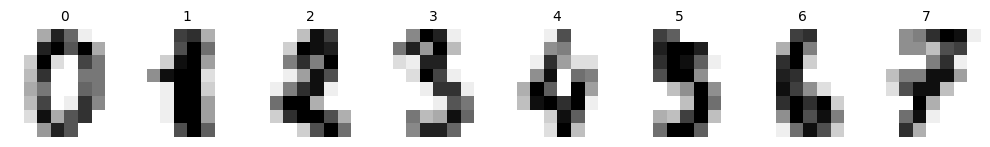

In [3]:
# A quick look at what the model is being asked to read.
fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
for ax, img, lab in zip(axes, digits.images[:8], digits.target[:8]):
    ax.imshow(img, cmap="gray_r")
    ax.set_title(int(lab), fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Pillar 3 — why "write it as a matrix multiply" is not style advice

The lecture insists that batch matrix form is a *performance* decision rather than a notational
convenience. That is easy to test directly.

Applying the hypothesis $h_\theta(x) = \theta^{\mathsf{T}} x$ to every example can be written two
ways that compute exactly the same numbers:

- a Python loop over rows, each one a vector-matrix product
- a single matrix product $X\theta$

Both are "correct". Only one is usable.

In [4]:
theta = np.random.randn(n, k) * 0.01

def predict_loop(X, theta):
    """One row at a time. Mathematically identical to X @ theta."""
    out = np.empty((X.shape[0], theta.shape[1]))
    for i in range(X.shape[0]):
        out[i] = theta.T @ X[i]      # (k, n) @ (n,) -> (k,)
    return out

def predict_matrix(X, theta):
    """The whole batch in one operation."""
    return X @ theta                 # (m, n) @ (n, k) -> (m, k)

# Confirm they agree before timing anything.
assert np.allclose(predict_loop(X_train, theta), predict_matrix(X_train, theta))
print("both routes produce identical output")

both routes produce identical output


In [5]:
def timeit(fn, *args, repeats=20):
    fn(*args)                                    # warm up
    t0 = time.perf_counter()
    for _ in range(repeats):
        fn(*args)
    return (time.perf_counter() - t0) / repeats

t_loop   = timeit(predict_loop,   X_train, theta)
t_matrix = timeit(predict_matrix, X_train, theta)

print(f"python loop      : {t_loop*1e3:8.3f} ms")
print(f"matrix multiply  : {t_matrix*1e3:8.3f} ms")
print(f"speed-up         : {t_loop/t_matrix:8.1f}x")

python loop      :    1.995 ms
matrix multiply  :    0.044 ms
speed-up         :     45.8x


The gap is entirely about how the work reaches the hardware. The loop pays Python interpreter
overhead per row and touches memory unpredictably; the matrix product hands one contiguous block
to a BLAS kernel that uses vectorised instructions and cache-friendly blocking.

This is the same reason the lecture stresses that GPUs matter: a GPU is a machine for doing this
one operation extremely fast. If your computation is not expressed as large matrix operations,
the hardware cannot help you.

## 3. Pillars 1 and 2 — the whole training loop

Here is a complete classifier: hypothesis, loss, gradient, and stochastic gradient descent. The
derivation behind the gradient line is lecture 2 and the next notebook; for now the point is the
*size* of the thing.

Six lines of real work replace what used to be a research project.

In [6]:
def softmax_regression_epoch(X, y, theta, lr=0.5, B=64):
    """One pass of SGD over the data. theta is updated in place."""
    for i in range(0, X.shape[0], B):
        Xb, yb = X[i:i+B], y[i:i+B]
        logits = Xb @ theta                                   # (B, k)
        Z  = np.exp(logits - logits.max(1, keepdims=True))    # stabilised
        Z /= Z.sum(1, keepdims=True)                          # rows sum to 1
        Iy = np.zeros_like(Z)
        Iy[np.arange(yb.size), yb] = 1                        # one-hot labels
        theta -= (lr / yb.size) * Xb.T @ (Z - Iy)             # the gradient step

def error_rate(X, y, theta):
    return float((np.argmax(X @ theta, axis=1) != y).mean())

final train error: 0.0275
final test  error: 0.0422   (accuracy 0.9578)


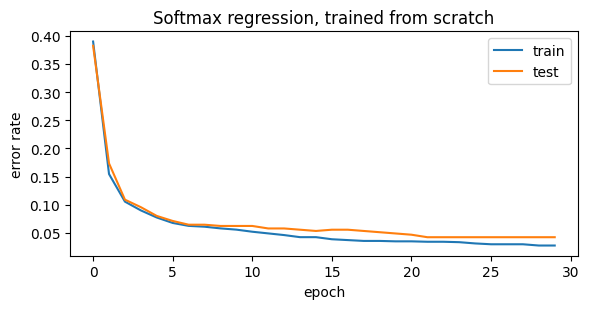

In [7]:
theta = np.zeros((n, k))
history = []

for epoch in range(30):
    softmax_regression_epoch(X_train, y_train, theta)
    history.append((error_rate(X_train, y_train, theta),
                    error_rate(X_test,  y_test,  theta)))

tr, te = zip(*history)
print(f"final train error: {tr[-1]:.4f}")
print(f"final test  error: {te[-1]:.4f}   (accuracy {1-te[-1]:.4f})")

plt.figure(figsize=(6, 3.2))
plt.plot(tr, label="train")
plt.plot(te, label="test")
plt.xlabel("epoch"); plt.ylabel("error rate"); plt.legend()
plt.title("Softmax regression, trained from scratch")
plt.tight_layout(); plt.show()

## 4. What this notebook actually demonstrated

- Writing computation as matrix operations is what makes it fast enough to be practical. The
  mathematics is unchanged; the runtime is not.
- A complete supervised learner is a few lines once the gradient is known — and the entire
  difficulty is hidden in that one gradient expression.

That hidden difficulty is the subject of the next five notebooks. We derive the gradient by hand
(lectures 2–4), then build the machinery that derives it for us (lectures 5–6).

| Notebook | Builds |
|---|---|
| Lecture 2 | Softmax regression, and where the gradient comes from |
| Lecture 3 | Why a nonlinearity is required; two-layer networks |
| Lecture 4 | Backpropagation for an arbitrary $L$-layer network |
| Lecture 5 | Forward- and reverse-mode automatic differentiation |
| Lecture 6 | A miniature autodiff framework, then a network trained with it |